ENVIRONNEMENT & CHARGEMENT DES DONNÉES

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des visualisations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# Affichage complet des colonnes
pd.set_option('display.max_columns', 50)

In [27]:
# Chargement des datasets avec conversion de la colonne date
train = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
test = pd.read_csv('../data/raw/test.csv', parse_dates=['date'])

print(f"Dimensions Train : {train.shape[0]:,} lignes, {train.shape[1]} colonnes".replace(',', ' '))
print(f"Dimensions Test  : {test.shape[0]:,} lignes, {test.shape[1]} colonnes".replace(',', ' '))

Dimensions Train : 913 000 lignes  4 colonnes
Dimensions Test  : 45 000 lignes  4 colonnes


In [28]:
display(train.head())

print("--- Infos Train ---")
print(train.info())

print("\n--- Valeurs manquantes ---")
print("Train :")
print(train.isnull().sum())
print("\nTest :")
print(test.isnull().sum())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


--- Infos Train ---
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB
None

--- Valeurs manquantes ---
Train :
date     0
store    0
item     0
sales    0
dtype: int64

Test :
id       0
date     0
store    0
item     0
dtype: int64


In [29]:
# Analyse des périodes
train_start, train_end = train['date'].min(), train['date'].max()
test_start, test_end = test['date'].min(), test['date'].max()

print("--- Périodes temporelles ---")
print(f"Train : du {train_start.strftime('%Y-%m-%d')} au {train_end.strftime('%Y-%m-%d')} "
      f"({(train_end - train_start).days + 1} jours)")
print(f"Test  : du {test_start.strftime('%Y-%m-%d')} au {test_end.strftime('%Y-%m-%d')} "
      f"({(test_end - test_start).days + 1} jours)")

# Vérification de continuité entre train et test
gap = (test_start - train_end).days
print(f"Intervalle entre Train et Test : {gap} jour(s) (1 = continuité parfaite)")

--- Périodes temporelles ---
Train : du 2013-01-01 au 2017-12-31 (1826 jours)
Test  : du 2018-01-01 au 2018-03-31 (90 jours)
Intervalle entre Train et Test : 1 jour(s) (1 = continuité parfaite)


In [30]:
# Nombre de magasins et d'articles
n_stores = train['store'].nunique()
n_items = train['item'].nunique()
n_days_train = (train_end - train_start).days + 1
n_days_test = (test_end - test_start).days + 1

n_series = n_stores * n_items
expected_train_rows = n_series * n_days_train
expected_test_rows = n_series * n_days_test

print("--- Structure des séries ---")
print(f"Magasins uniques : {n_stores}")
print(f"Produits uniques : {n_items}")
print(f"Nombre total de séries temporelles distinctes : {n_series} (stores x items)")

print("\n--- Contrôle de complétude (zéro jour manquant ?) ---")
print(f"Train attendu : {expected_train_rows:,} | Train réel : {len(train):,} -> {'PARFAIT' if expected_train_rows == len(train) else 'ATTENTION: trous détectés'}")
print(f"Test attendu  : {expected_test_rows:,}  | Test réel  : {len(test):,}  -> {'PARFAIT' if expected_test_rows == len(test) else 'ATTENTION: trous détectés'}")

# Vérification cold-start
stores_in_both = set(test['store']).issubset(set(train['store']))
items_in_both = set(test['item']).issubset(set(train['item']))
print(f"\nTous les stores du test sont dans le train : {stores_in_both}")
print(f"Tous les items du test sont dans le train  : {items_in_both}")

--- Structure des séries ---
Magasins uniques : 10
Produits uniques : 50
Nombre total de séries temporelles distinctes : 500 (stores x items)

--- Contrôle de complétude (zéro jour manquant ?) ---
Train attendu : 913,000 | Train réel : 913,000 -> PARFAIT
Test attendu  : 45,000  | Test réel  : 45,000  -> PARFAIT

Tous les stores du test sont dans le train : True
Tous les items du test sont dans le train  : True


In [31]:
# Contrôle strict : absence de doublons et complétude individuelle de chaque série
duplicates_train = train.duplicated(subset=['date', 'store', 'item']).sum()
print(f"Doublons stricts (date x store x item) : {duplicates_train}")

counts_per_series = train.groupby(['store', 'item'])['date'].nunique()
all_complete = (counts_per_series == train['date'].nunique()).all()
print(f"Chacune des 500 séries possède exactement {train['date'].nunique()} jours uniques : {all_complete}")

Doublons stricts (date x store x item) : 0
Chacune des 500 séries possède exactement 1826 jours uniques : True


In [32]:
print("--- Statistiques descriptives des ventes (`sales`) ---")
display(train['sales'].describe())

# Vérification des cas limites
zeros = (train['sales'] == 0).sum()
negatives = (train['sales'] < 0).sum()

print(f"\nNombre de ventes égales à 0 : {zeros} ({zeros / len(train):.2%})")
print(f"Nombre de ventes négatives : {negatives}")

--- Statistiques descriptives des ventes (`sales`) ---


count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


Nombre de ventes égales à 0 : 1 (0.00%)
Nombre de ventes négatives : 0


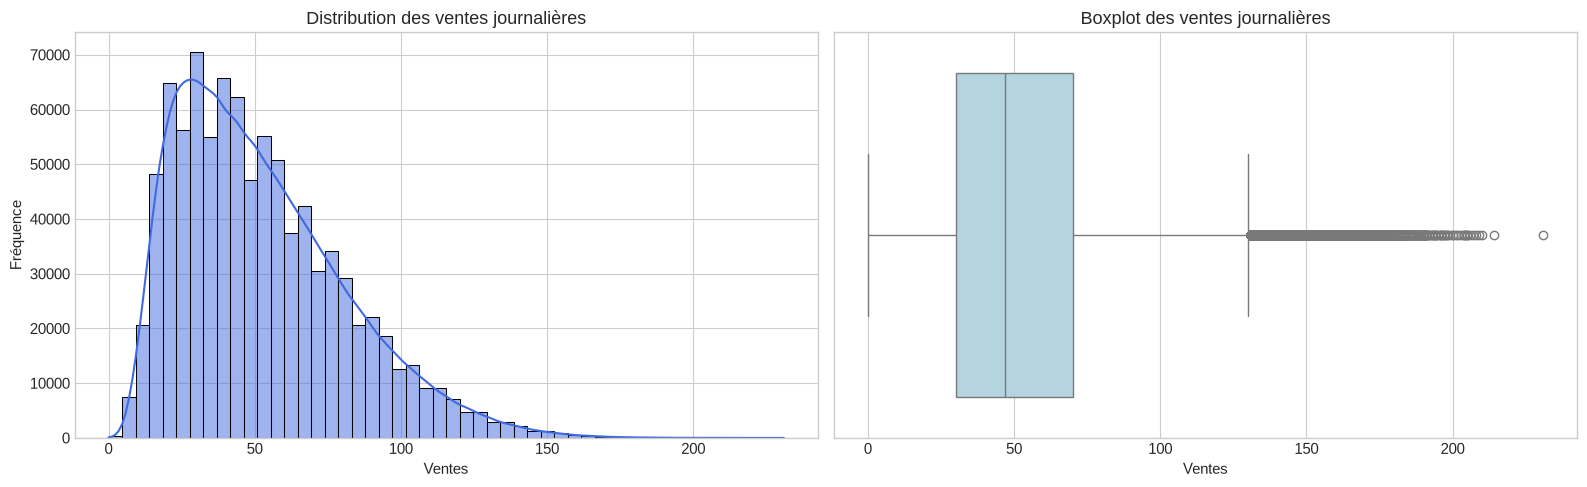

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme / KDE
sns.histplot(train['sales'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title("Distribution des ventes journalières")
axes[0].set_xlabel("Ventes")
axes[0].set_ylabel("Fréquence")

# Boxplot pour repérer d'éventuels outliers extrêmes
sns.boxplot(x=train['sales'], ax=axes[1], color='lightblue')
axes[1].set_title("Boxplot des ventes journalières")
axes[1].set_xlabel("Ventes")

plt.tight_layout()
plt.show()

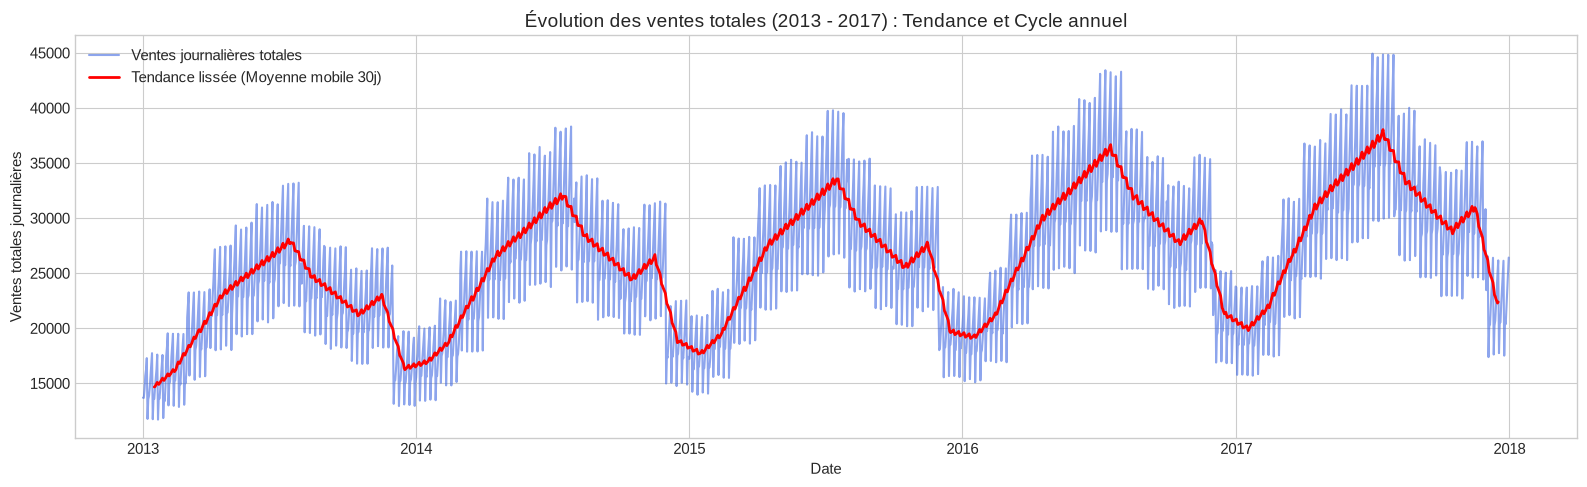

In [34]:
# On agrège toutes les ventes par jour (tous magasins et produits confondus)
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='royalblue', alpha=0.6, label='Ventes journalières totales')

# Moyenne mobile sur 30 jours pour "lisser" le bruit et voir la vraie tendance
daily_sales['rolling_30'] = daily_sales['sales'].rolling(window=30, center=True).mean()
plt.plot(daily_sales['date'], daily_sales['rolling_30'], color='red', linewidth=2, label='Tendance lissée (Moyenne mobile 30j)')

plt.title("Évolution des ventes totales (2013 - 2017) : Tendance et Cycle annuel", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Ventes totales journalières")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_10939/843233285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_eda, x='dayofweek', y='sales', order=days_order, palette='crest', ax=axes[1])


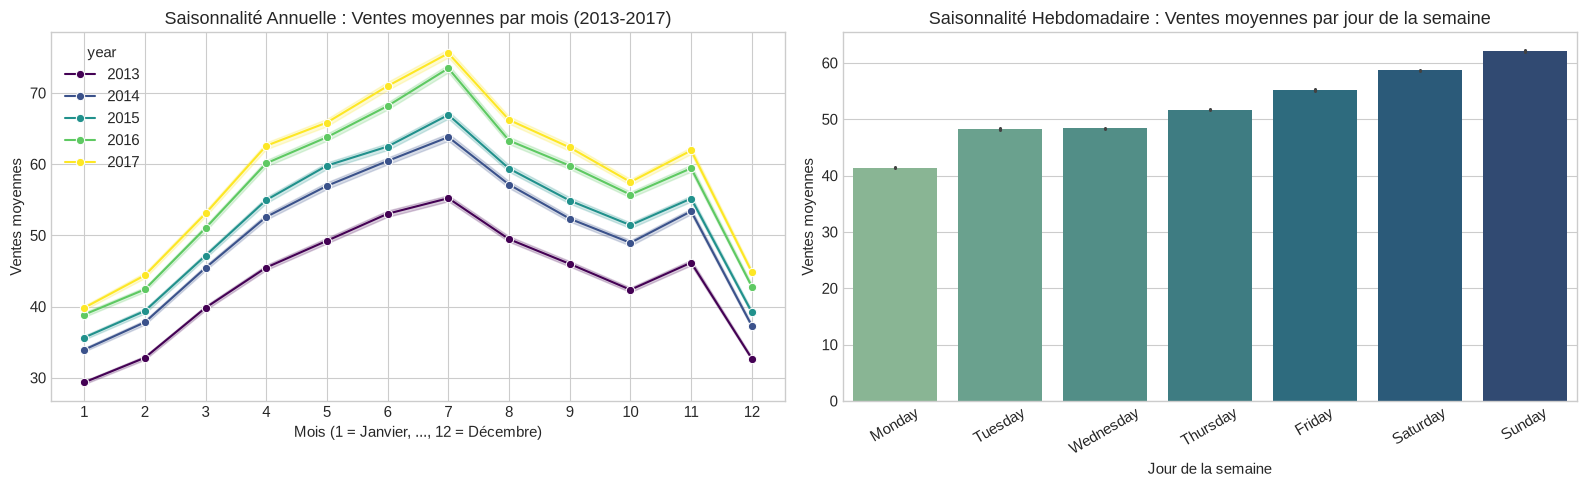

In [35]:
# Extraction temporaire des composantes pour la visualisation
train_eda = train.copy()
train_eda['year'] = train_eda['date'].dt.year
train_eda['month'] = train_eda['date'].dt.month
train_eda['dayofweek'] = train_eda['date'].dt.day_name()

# Ordre correct des jours
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Ventes moyennes par mois (comparaison d'une année sur l'autre)
sns.lineplot(data=train_eda, x='month', y='sales', hue='year', palette='viridis', marker='o', ax=axes[0])
axes[0].set_title("Saisonnalité Annuelle : Ventes moyennes par mois (2013-2017)")
axes[0].set_xlabel("Mois (1 = Janvier, ..., 12 = Décembre)")
axes[0].set_ylabel("Ventes moyennes")
axes[0].set_xticks(range(1, 13))

# 2. Ventes moyennes par jour de la semaine
sns.barplot(data=train_eda, x='dayofweek', y='sales', order=days_order, palette='crest', ax=axes[1])
axes[1].set_title("Saisonnalité Hebdomadaire : Ventes moyennes par jour de la semaine")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_ylabel("Ventes moyennes")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

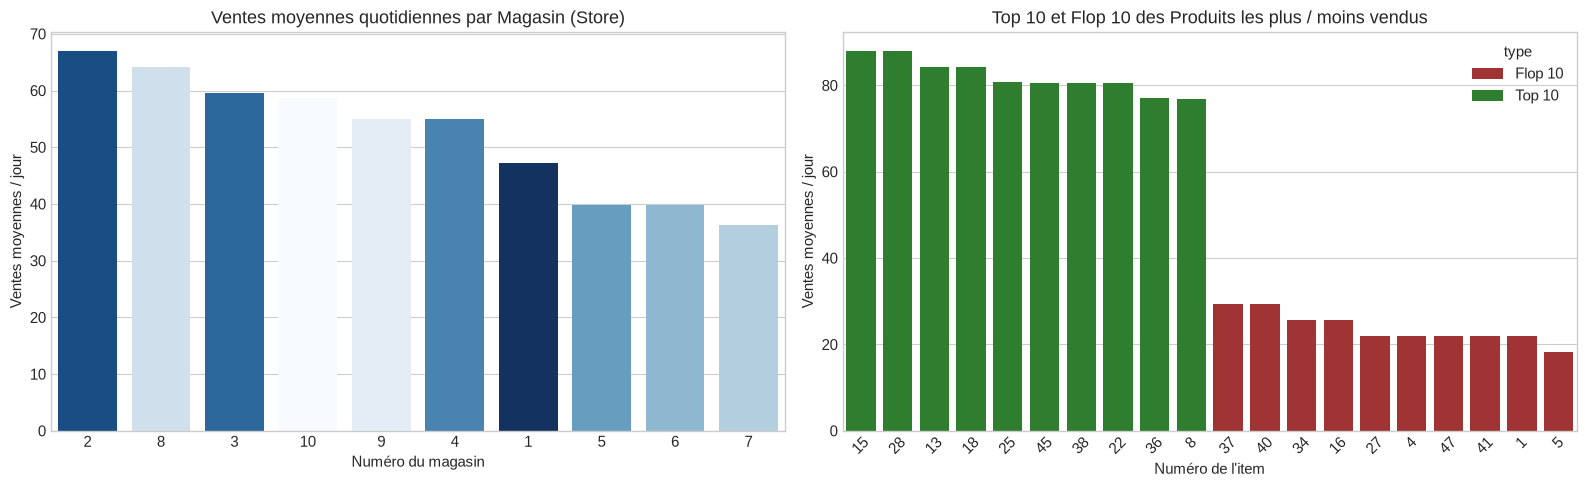

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Performance par magasin (ordonné du meilleur au moins bon)
store_sales = train.groupby('store')['sales'].mean().reset_index().sort_values(by='sales', ascending=False)
sns.barplot(data=store_sales, x='store', y='sales', order=store_sales['store'], hue='store', palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title("Ventes moyennes quotidiennes par Magasin (Store)")
axes[0].set_xlabel("Numéro du magasin")
axes[0].set_ylabel("Ventes moyennes / jour")

# 2. Performance des produits (Top 10 vs Flop 10)
item_sales = train.groupby('item')['sales'].mean().reset_index().sort_values(by='sales', ascending=False)
top10_flop10 = pd.concat([item_sales.head(10), item_sales.tail(10)])
top10_flop10['type'] = ['Top 10'] * 10 + ['Flop 10'] * 10

sns.barplot(data=top10_flop10, x='item', y='sales', hue='type', order=top10_flop10['item'], dodge=False, palette={'Top 10': 'forestgreen', 'Flop 10': 'firebrick'}, ax=axes[1])
axes[1].set_title("Top 10 et Flop 10 des Produits les plus / moins vendus")
axes[1].set_xlabel("Numéro de l'item")
axes[1].set_ylabel("Ventes moyennes / jour")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

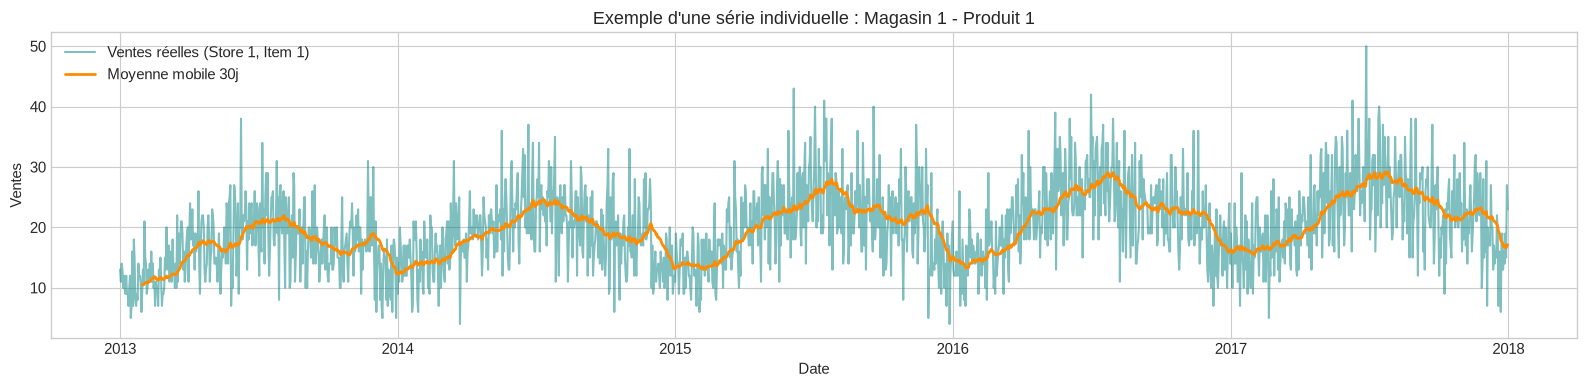

In [37]:
# Regardons à quoi ressemble concrètement 1 seule série parmi les 500
sample_series = train[(train['store'] == 1) & (train['item'] == 1)]

plt.figure(figsize=(16, 4))
plt.plot(sample_series['date'], sample_series['sales'], color='teal', alpha=0.5, label='Ventes réelles (Store 1, Item 1)')
plt.plot(sample_series['date'], sample_series['sales'].rolling(30).mean(), color='darkorange', linewidth=2, label='Moyenne mobile 30j')
plt.title("Exemple d'une série individuelle : Magasin 1 - Produit 1", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.legend()
plt.tight_layout()
plt.show()

## Synthèse de l'Exploration des Données (EDA) & Prochaines Étapes

### Principaux constats :
1. **Intégrité des données :** 
   - 500 séries temporelles (10 magasins × 50 produits) observées sur 5 ans (2013-2017) sans aucune valeur manquante ni rupture de date.
   - Période à prédire (Test) : 90 jours (Janvier à Mars 2018).
2. **Distribution de la cible (`sales`) :**
   - Distribution asymétrique positive (mode autour de 30-40, longue traîne jusqu'à ~200).
   - Demande continue (pas d'intermittence, ventes quotidiennes stables). Une transformation $\log(1 + x)$ pourra être bénéfique.
3. **Composantes temporelles majeures :**
   - **Tendance :** Croissance annuelle régulière et constante d'environ 8 à 10% par an.
   - **Saisonnalité annuelle :** Creux en janvier/février, pic massif en juillet.
   - **Saisonnalité hebdomadaire :** Hausse continue du lundi (creux) au dimanche (pic).
4. **Hétérogénéité des séries :**
   - Fort effet magasin (Store 2 et 8 > Store 7).
   - Très fort effet produit (Top items vendent 4.5x plus que les Flop items).

---

### Stratégie pour le Notebook 02 (Feature Engineering) :
Pour permettre à nos modèles de capturer ces motifs, nous allons créer 4 familles de variables :
1. **Variables de calendrier :** `dayofweek`, `month`, `year`, `dayofyear`, `is_weekend`.
2. **Variables de retard (Lags) :** Décalages temporels (ventes passées). *Attention : le décalage minimum devra être de 90 jours pour correspondre à l'horizon du test sans fuite de données (data leakage).*
3. **Moyennes mobiles (Rolling statistics) :** Fenêtres glissantes sur les ventes passées pour capter la tendance récente.
4. **Encodage / Statistiques de groupe :** Ventes moyennes par magasin et par item.